In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Cleaned_forest_dataset.csv')

In [3]:
df.head()

,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df['classes'].value_counts()

classes
fire             132
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [5]:
df['classes'] = np.where(df['classes'].str.contains('not fire'), 0, 1)

In [6]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [7]:
df.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [8]:
df.tail()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
239,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
240,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
241,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
242,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
243,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [9]:
# Spliting Features into Independent and dependent feature
x = df[[x for x in df.columns if x != 'fwi']]

In [10]:
y = df['fwi']

In [11]:
# Train Test split --
from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

<Axes: >

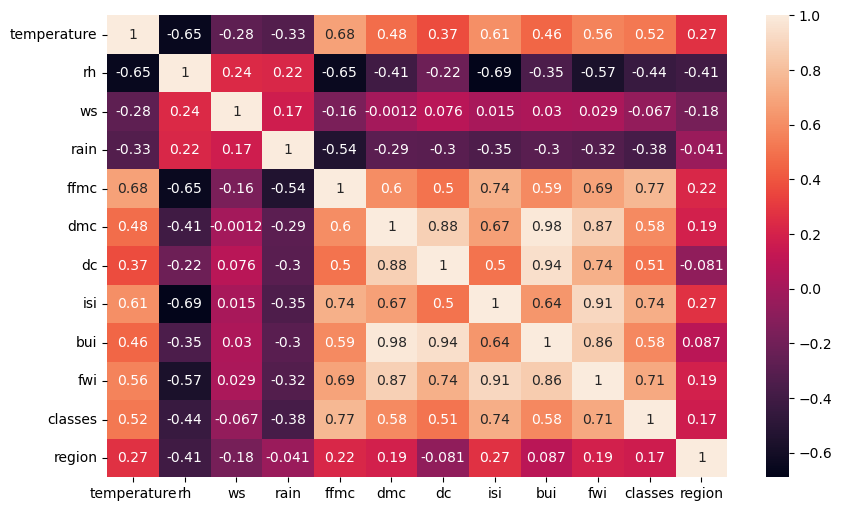

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True)

In [14]:
# Feature selection based on Correlations --
def Corr_chk(dataset, threshold):
    thrs_above_set = set() # due to need of only unique feature
    corr_matrix = dataset.corr()
    for col in range(len(corr_matrix.columns)):
        for row in range(col):
            if abs(corr_matrix.iloc[col, row]) > threshold:
                thrs_above_set.add(corr_matrix.columns[col])
    return thrs_above_set

In [15]:
high_corr = list(Corr_chk(x_train, .85)) # Here the threshold is 0.85

In [16]:
# Dropping the highly correlated feature --
x_train.drop(high_corr, axis=1, inplace=True)
x_test.drop(high_corr, axis=1, inplace=True)

In [17]:
high_corr

['dc', 'bui']

In [18]:
x_train.head()

,temperature,rh,ws,rain,ffmc,dmc,isi,classes,region
115,29,65,19,0.6,68.3,5.5,1.5,0,0
181,36,56,16,0.0,88.9,23.8,8.2,1,1
225,31,72,14,0.0,84.2,8.3,3.8,1,1
68,32,60,18,0.3,77.1,11.3,2.2,0,0
104,25,86,21,4.6,40.9,1.3,0.1,0,0


In [19]:
x_train.shape, x_test.shape

((183, 9), (61, 9))

#### Scaling the data or Standardization

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
x_train_scaler = scaler.fit_transform(x_train)

In [23]:
x_test_scaler = scaler.transform(x_test)

<Axes: >

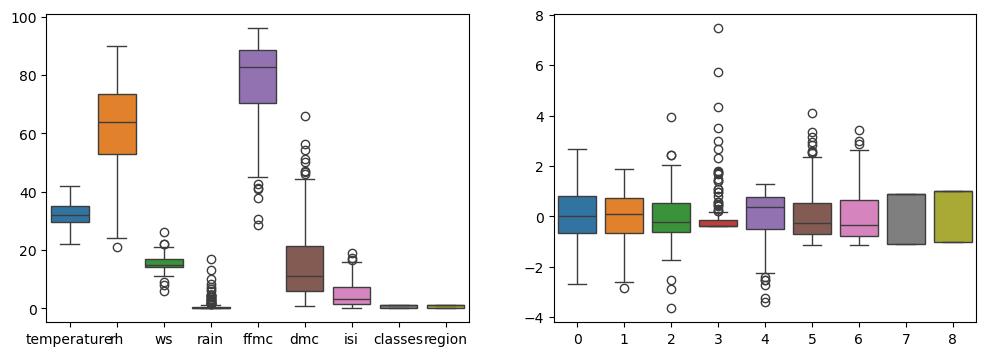

In [24]:
fig, axs = plt.subplots(1, 2, figsize=[12, 4])

sns.boxplot(x_train, ax=axs[0])
sns.boxplot(x_train_scaler, ax=axs[1])

# Linear model implementation ---

In [133]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
reggression = LinearRegression()

reggression.fit(x_train_scaler, y_train)
y_pred = reggression.predict(x_test_scaler)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r_score = r2_score(y_test, y_pred)

print(f'MAE= {mae} MSE= {mse} R2-score = {r_score}')

MAE= 0.6631132191793875 MSE= 0.7507663135005962 R2-score = 0.9870391878204444


In [134]:
# checking model is overfitted or not!
train_score = reggression.score(x_train_scaler, y_train)
test_score = reggression.score(x_test_scaler, y_test)
print(f'train score is -{train_score} & test_score is - {test_score}')

train score is -0.9468983590854427 & test_score is - 0.9870391878204444


<Axes: xlabel='fwi'>

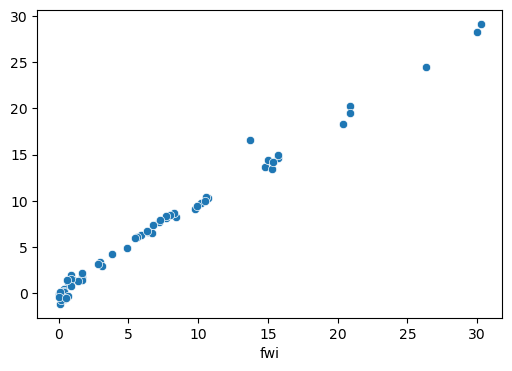

In [135]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred) #Q -- If Y_test & Y_pred create linear scatter plot then the model is good.

#### Cross validation for Linear model ---

In [136]:
from sklearn.model_selection import cross_val_score

In [137]:
cv_score = cross_val_score(reggression, x_train_scaler, y_train, cv=5, scoring='r2')
print(cv_score)
avg_lnr = cv_score.mean()

[0.8923876  0.97124392 0.98461488 0.96895192 0.84530237]


# Comparing with other models --
## Ridge & Lasso

In [138]:
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(alphas=(0.1, 5.0, 10), cv=5)

In [139]:
ridge.fit(x_train_scaler, y_train)

RidgeCV(alphas=(0.1, 5.0, 10), cv=5)

In [140]:
ridge.alpha_

np.float64(5.0)

In [141]:
print('R2-score ', r2_score(y_test, ridge.predict(x_test_scaler)))

R2-score  0.9829858740040569


#### cross validation--

In [142]:
from sklearn.model_selection import cross_val_score

In [143]:
rdg_score = cross_val_score(ridge,x_train_scaler, y_train, cv=5, scoring='r2')
avg_ridge = rdg_score.mean()

#### Lasso regression model implementation ---

In [144]:
from sklearn.linear_model import LassoCV
lasso = LassoCV(cv=5, n_alphas=50)

In [145]:
lasso.fit(x_train_scaler, y_train)
print('R2 score -', r2_score(y_test, lasso.predict(x_test_scaler)))

R2 score - 0.9859408641727965


In [146]:
# crosss validation -
from sklearn.model_selection import cross_val_score
ls_score = cross_val_score(lasso, x_train_scaler, y_train, cv=5, scoring='r2')
ls_avg = ls_score.mean()

#### Comparing avg model score --

In [147]:
print(f'Linear model score - {avg_lnr} Ridge model score - {avg_ridge} Lasso model score - {ls_avg}')

Linear model score - 0.932500138472206 Ridge model score - 0.9293299888146235 Lasso model score - 0.9328755869581524


# Conclusion -
Due to similar R2_score of three different model, so we can select Linear Model. 